mkdir frontend and backend <br>
cd into `backend` and install the following dependencies

```bash
npm init -y
npm install express pg cors dotenv express-list-endpoints
npm install nodemon -D
```


Edit the package.json file to inculde dev and start keywords under script. <br>

```bash
"scripts": {
    "start": "node index.js",
    "dev": "nodemon index.js"
  },
```
Also add "type": "module" to the package.json file for modern ES module import/export syntax.

> Use npm run dev to start development server.

## PostgreSQL pgAdmin Setup

1.) Run Docker Desktop  <br>
2.) Run this as sanity check before next command : docker ps <br>
3.) Then Run this in terminal : 

```bash
docker run -p 5050:80 -e 'PGADMIN_DEFAULT_EMAIL=malcolmiscalm@gmail.com' -e 'PGADMIN_DEFAULT_PASSWORD=password' -d dpage/pgadmin4
````
4.) naviage to the port , ie 5050 in this case and login into the web browser page <br>
5.) docker rename <silly_name> <new_name>


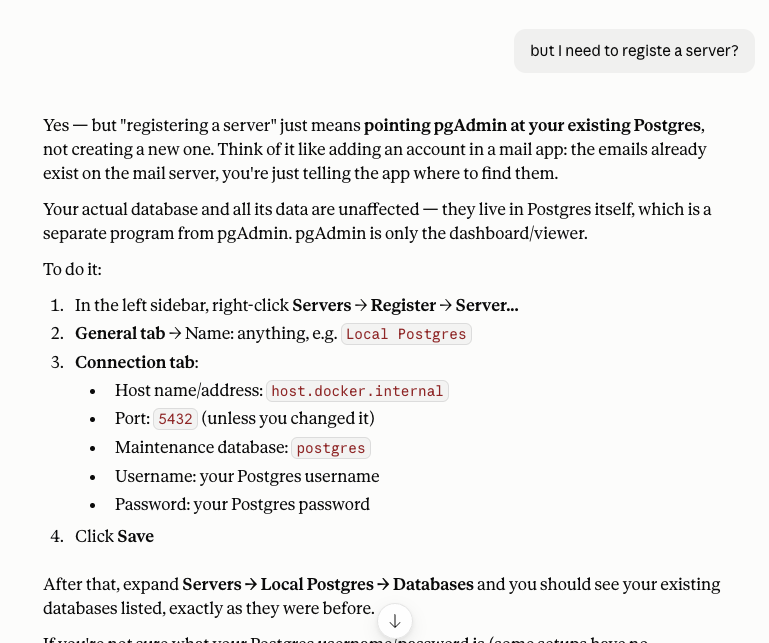

## PostgreSQL pgAdmin Startup

The key thing: never run the original docker run ... command again for regular use — that creates a brand new container each time (which would lose your registered server connections). Use docker stop pgadmin / docker start pgadmin to toggle it, and docker run only that one time to create it initially.


Create a new database called "pern_todo" in pgAdmin. <br>
 Then create a new table called "todo" with the following columns

>> Right click for Query Tool to write the SQL script below : 

 ```sql
 CREATE TABLE todo (
todo_id SERIAL PRIMARY KEY,
description VARCHAR(255) NOT NULL,
completed BOOLEAN DEFAULT FALSE
)
```

```sql
-- 1. Add the column as blank
ALTER TABLE todo ADD COLUMN created_at TIMESTAMPTZ;

-- 2. Apply the default generator strictly for future row entries
ALTER TABLE todo ALTER COLUMN created_at SET DEFAULT NOW();
```

## Connecting to the database


```javascript
------------------backend/db.js------------------
import { Pool } from "pg";

// This is the connection pool for the PostgreSQL database. It allows us to connect to the database and execute queries.
const pool = new Pool({
  user: "postgres",
  password: "password",
  host: "localhost",
  port: 5434,
  database: "PERN_todo_db",
});

export default pool;

------------------backend/index.js------------------

// This file is the entry point for the backend server. It sets up the Express application, connects to the database, and starts the server.
import express from "express";
import cors from "cors";
import todoRoutes from "./routes/todos.js";

// Create an instance of the Express application
const app = express();

// use cors to allow cross-origin requests
app.use(cors());

// // Middleware to parse JSON bodies, now we can access the request body as req.body
app.use(express.json());

// Use the todos router for all routes starting with /todos
app.use("/todos", todoRoutes);

// app.get("/", (req, res) => {
//   res.send("API is running...");
// });

app.listen(3000, () => {
  console.log(`Server is running on port 3000`);
});


------------------backend/routes/todos.js------------------
import { Router } from "express";
import pool from "../db.js";

const router = Router();

// Create a new todo
router.post("/", async (req, res) => {
  try {
    const { description, completed } = req.body;
    const newTodo = await pool.query(
      "INSERT INTO todo (description, completed) VALUES ($1, $2) RETURNING *",
      [description, completed || false],
    );
    res.json(newTodo.rows[0]); // The first and only element of the rows array is the newly created todo
  } catch (err) {
    console.error(err.message);
    res.status(500).send("Server error wth omg !");
  }
});

export default router;

```

## Simulating post request with Postman

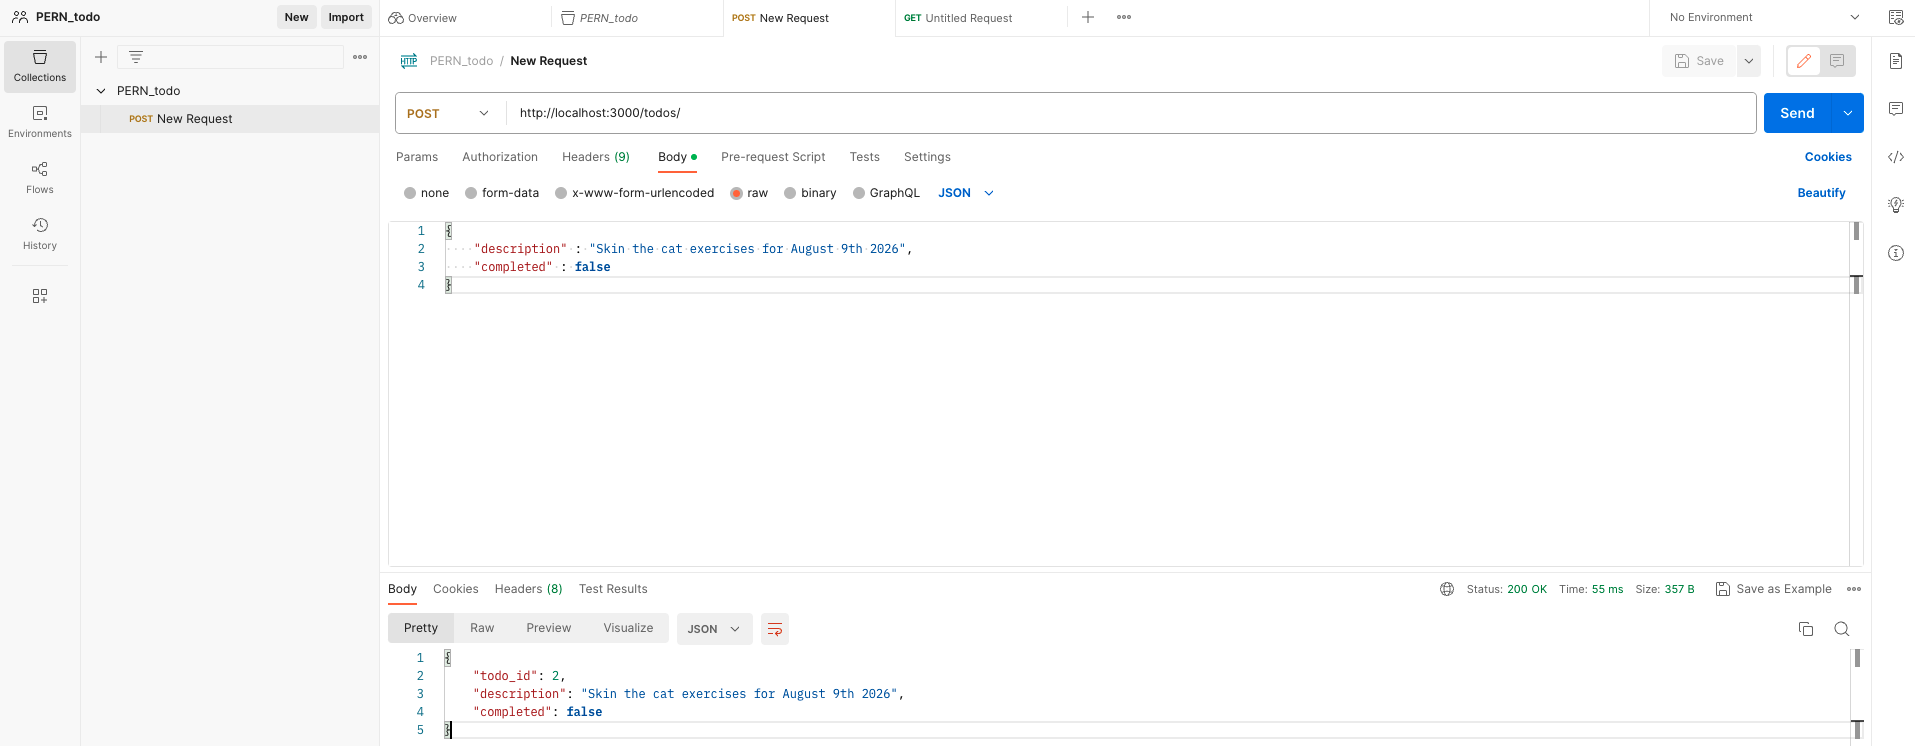


Then we can use Select * to view the data in pgAdmin 

## Using a PostgreSQL Function to Return a Formatted String
> Head to your_db/schema/functions and right-click for Query Tool. Never use Create Function as it will trigger the GUI helper

```sql
CREATE OR REPLACE FUNCTION print_user_age(
    user_name TEXT,
    user_age INT
)
RETURNS TEXT
LANGUAGE plpgsql
AS $$
BEGIN
    RETURN format('Hello, %s! You are %s years old.', user_name, user_age);
END;
$$;
```

Make sure to highlight the entire function and click the "Execute/Run" button to create the function in your database. You can then call the function using a SELECT statement, like this:

```sql      
SELECT print_user_age('Alice', 30);
```

# Creating audit-log table

## Safely remove the old table
```sql
DROP TABLE IF EXISTS todo_audit CASCADE;
```

## Re-create the todo_audit table with a constraint
```sql
create table todo_audit (
todo_id SERIAL,
description VARCHAR(255) NOT NULL,
completed BOOLEAN,
edit_operation VARCHAR(255) CONSTRAINT edit_constraint check (edit_operation in ('UPDATE')),
inserted_at TIMESTAMPTZ DEFAULT NOW()
);
```

## Edit the constraint
```sql
BEGIN;
-- 1. Remove the old constraint
ALTER TABLE todo_audit 
  DROP CONSTRAINT edit_constraint;
-- 2. Add the updated constraint
ALTER TABLE todo_audit
  ADD CONSTRAINT edit_constraint CHECK (edit_operation in ('UPDATE', 'DELETE'));
COMMIT;
```


## Create delete audit log

```sql
CREATE OR REPLACE FUNCTION create_delete_audit_log(
    target_id INT
)
RETURNS VOID 
LANGUAGE plpgsql
AS $$
BEGIN
    WITH deleted_rows AS (
        DELETE FROM todo
        WHERE todo_id = target_id
        RETURNING todo_id, description, completed
    )
    INSERT INTO todo_audit (todo_id, description, completed, edit_operation, inserted_at)
    SELECT todo_id, description, completed, 'DELETE', NOW()
    FROM deleted_rows;
END;
$$ ;
```

## View TABLE_CONSTRAINTS
```sql
SELECT CONSTRAINT_NAME, CONSTRAINT_TYPE 
FROM INFORMATION_SCHEMA.TABLE_CONSTRAINTS 
WHERE TABLE_NAME = 'your_table_name';
```


## update_log_audit

```sql
CREATE OR REPLACE FUNCTION update_audit_log(
    target_id INT,
    edit_operation TEXT,
    new_description TEXT DEFAULT NULL,
    new_completed BOOLEAN DEFAULT NULL,
	remarks TEXT DEFAULT NULL
)
RETURNS VOID
LANGUAGE plpgsql
AS $$
DECLARE
    output_text VARCHAR(20);
BEGIN

    -- Determine audit operation
    IF edit_operation = 'UPDATE-DESCRIPTION' THEN
        output_text := 'DESCRIPTION-UPDATE';

    ELSIF edit_operation = 'UPDATE-TOGGLE' THEN
        output_text := 'TOGGLE-UPDATE';

    ELSE
        RAISE EXCEPTION 'Invalid edit operation: %', edit_operation;
    END IF;
    -- First, save the current state of the todo
    INSERT INTO todo_audit (
        todo_id,
        description,
        completed,
        edit_operation,
        inserted_at, 
        remarks
    )
    SELECT
        todo_id, --source column in todo (match exactly)
        description, -- source column in todo
        completed, -- source column in todo
        output_text, -- declared variable that is conditioned in this PostgreSQL function
        NOW(), -- inbuilt function
        remarks -- passing straight from API endpoint, already conditioned by handleEditAudit in frontend
    FROM todo
    WHERE todo_id = target_id;


    -- Now update the todo
    IF edit_operation = 'UPDATE-DESCRIPTION' THEN

        UPDATE todo
        SET description = new_description
        WHERE todo_id = target_id;

    ELSIF edit_operation = 'UPDATE-TOGGLE' THEN

        UPDATE todo
        SET completed = new_completed
        WHERE todo_id = target_id;

    END IF;
END;
$$;
```